In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("Walmart_Sales.csv")

In [3]:
data.columns = data.columns.str.strip()
print("Columns in dataset:\n", data.columns)

Columns in dataset:
 Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')


In [4]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

In [5]:
data['Year'] = data['Date'].dt.year

In [6]:
yearly_sales = data.groupby('Year')['Weekly_Sales'].sum().reset_index()

In [7]:
print("\nTotal yearly sales of all stores:")
print(yearly_sales)


Total yearly sales of all stores:
   Year  Weekly_Sales
0  2010  2.288886e+09
1  2011  2.448200e+09
2  2012  2.000133e+09


In [8]:
years = yearly_sales['Year'].tolist()
sales = yearly_sales['Weekly_Sales'].tolist()

In [9]:
X = [i - years[len(years)//2] for i in years]
n = len(X)

In [10]:
x2 = [i**2 for i in X]
xy = [i*j for i,j in zip(X,sales)]

b = (n*sum(xy) - sum(sales)*sum(X)) / (n*sum(x2) - (sum(X)**2))
a = (sum(sales) - b*sum(X)) / n

linear_trend = [a + b*X[i] for i in range(n)]

print(f"\nLinear Trend Equation: y = {a:.2f} + {b:.2f}x")



Linear Trend Equation: y = 2245739662.37 + -144376630.53x


In [11]:
x3 = [i**3 for i in X]
x4 = [i**4 for i in X]
x2y = [i*j for i,j in zip(x2,sales)]

coeff = [
    [n, sum(X), sum(x2)],
    [sum(X), sum(x2), sum(x3)],
    [sum(x2), sum(x3), sum(x4)]
]

Y = [sum(sales), sum(xy), sum(x2y)]

A = np.array(coeff)
B = np.array(Y)

solution = np.linalg.solve(A,B)
a_poly, b_poly, c_poly = solution

poly_trend = [a_poly + b_poly*X[i] + c_poly*(X[i]**2) for i in range(n)]

print(f"Polynomial Trend Equation: y = {a_poly:.2f} + {b_poly:.2f}x + {c_poly:.2f}x²")


Polynomial Trend Equation: y = 2448200007.35 + -144376630.53x + -303690517.47x²


In [12]:
yearly_sales['Linear Trend'] = linear_trend
yearly_sales['Polynomial Trend'] = poly_trend

yearly_sales.set_index('Year', inplace=True)

print("\nFinal Trend Table:")
print(yearly_sales)



Final Trend Table:
      Weekly_Sales  Linear Trend  Polynomial Trend
Year                                              
2010  2.288886e+09  2.390116e+09      2.288886e+09
2011  2.448200e+09  2.245740e+09      2.448200e+09
2012  2.000133e+09  2.101363e+09      2.000133e+09


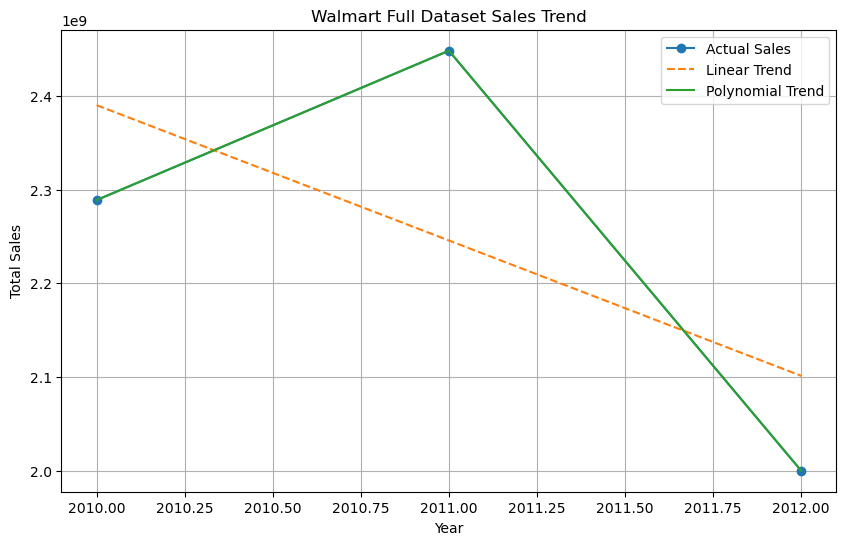

In [13]:
plt.figure(figsize=(10,6))

plt.plot(yearly_sales.index, yearly_sales['Weekly_Sales'], marker='o', label='Actual Sales')
plt.plot(yearly_sales.index, yearly_sales['Linear Trend'], linestyle='--', label='Linear Trend')
plt.plot(yearly_sales.index, yearly_sales['Polynomial Trend'], label='Polynomial Trend')

plt.title("Walmart Full Dataset Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)
plt.show()